In [ ]:
!pip install roboflow
!pip install ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="vxJRiY5ftq1mvmCq709S")
project = rf.workspace("roboflow-universe-projects").project("fall-detection-ca3o8")
version = project.version(4)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
loading Roboflow workspace...
loading Roboflow project...
[WARNING] we noticed you are downloading a `yolov8` datasets but you don't have `ultralytics` installed. Roboflow `.deploy` supports only models trained with `ultralytics==8.0.196`, to intall it `pip install ultralytics==8.0.196`.



Extracting Dataset Version Zip to Fall-Detection-4 in yolov8:: 100%|██████████| 21586/21586 [00:03<00:00, 5788.07it/s]


In [ ]:
!yolo task=detect mode=train model=yolov8m.pt data={dataset.location}/data.yaml epochs=10 imgsz=640

100% 49.7M/49.7M [00:01<00:00, 47.1MB/s]
Ultralytics YOLOv8.2.70 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/Fall-Detection-4/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_

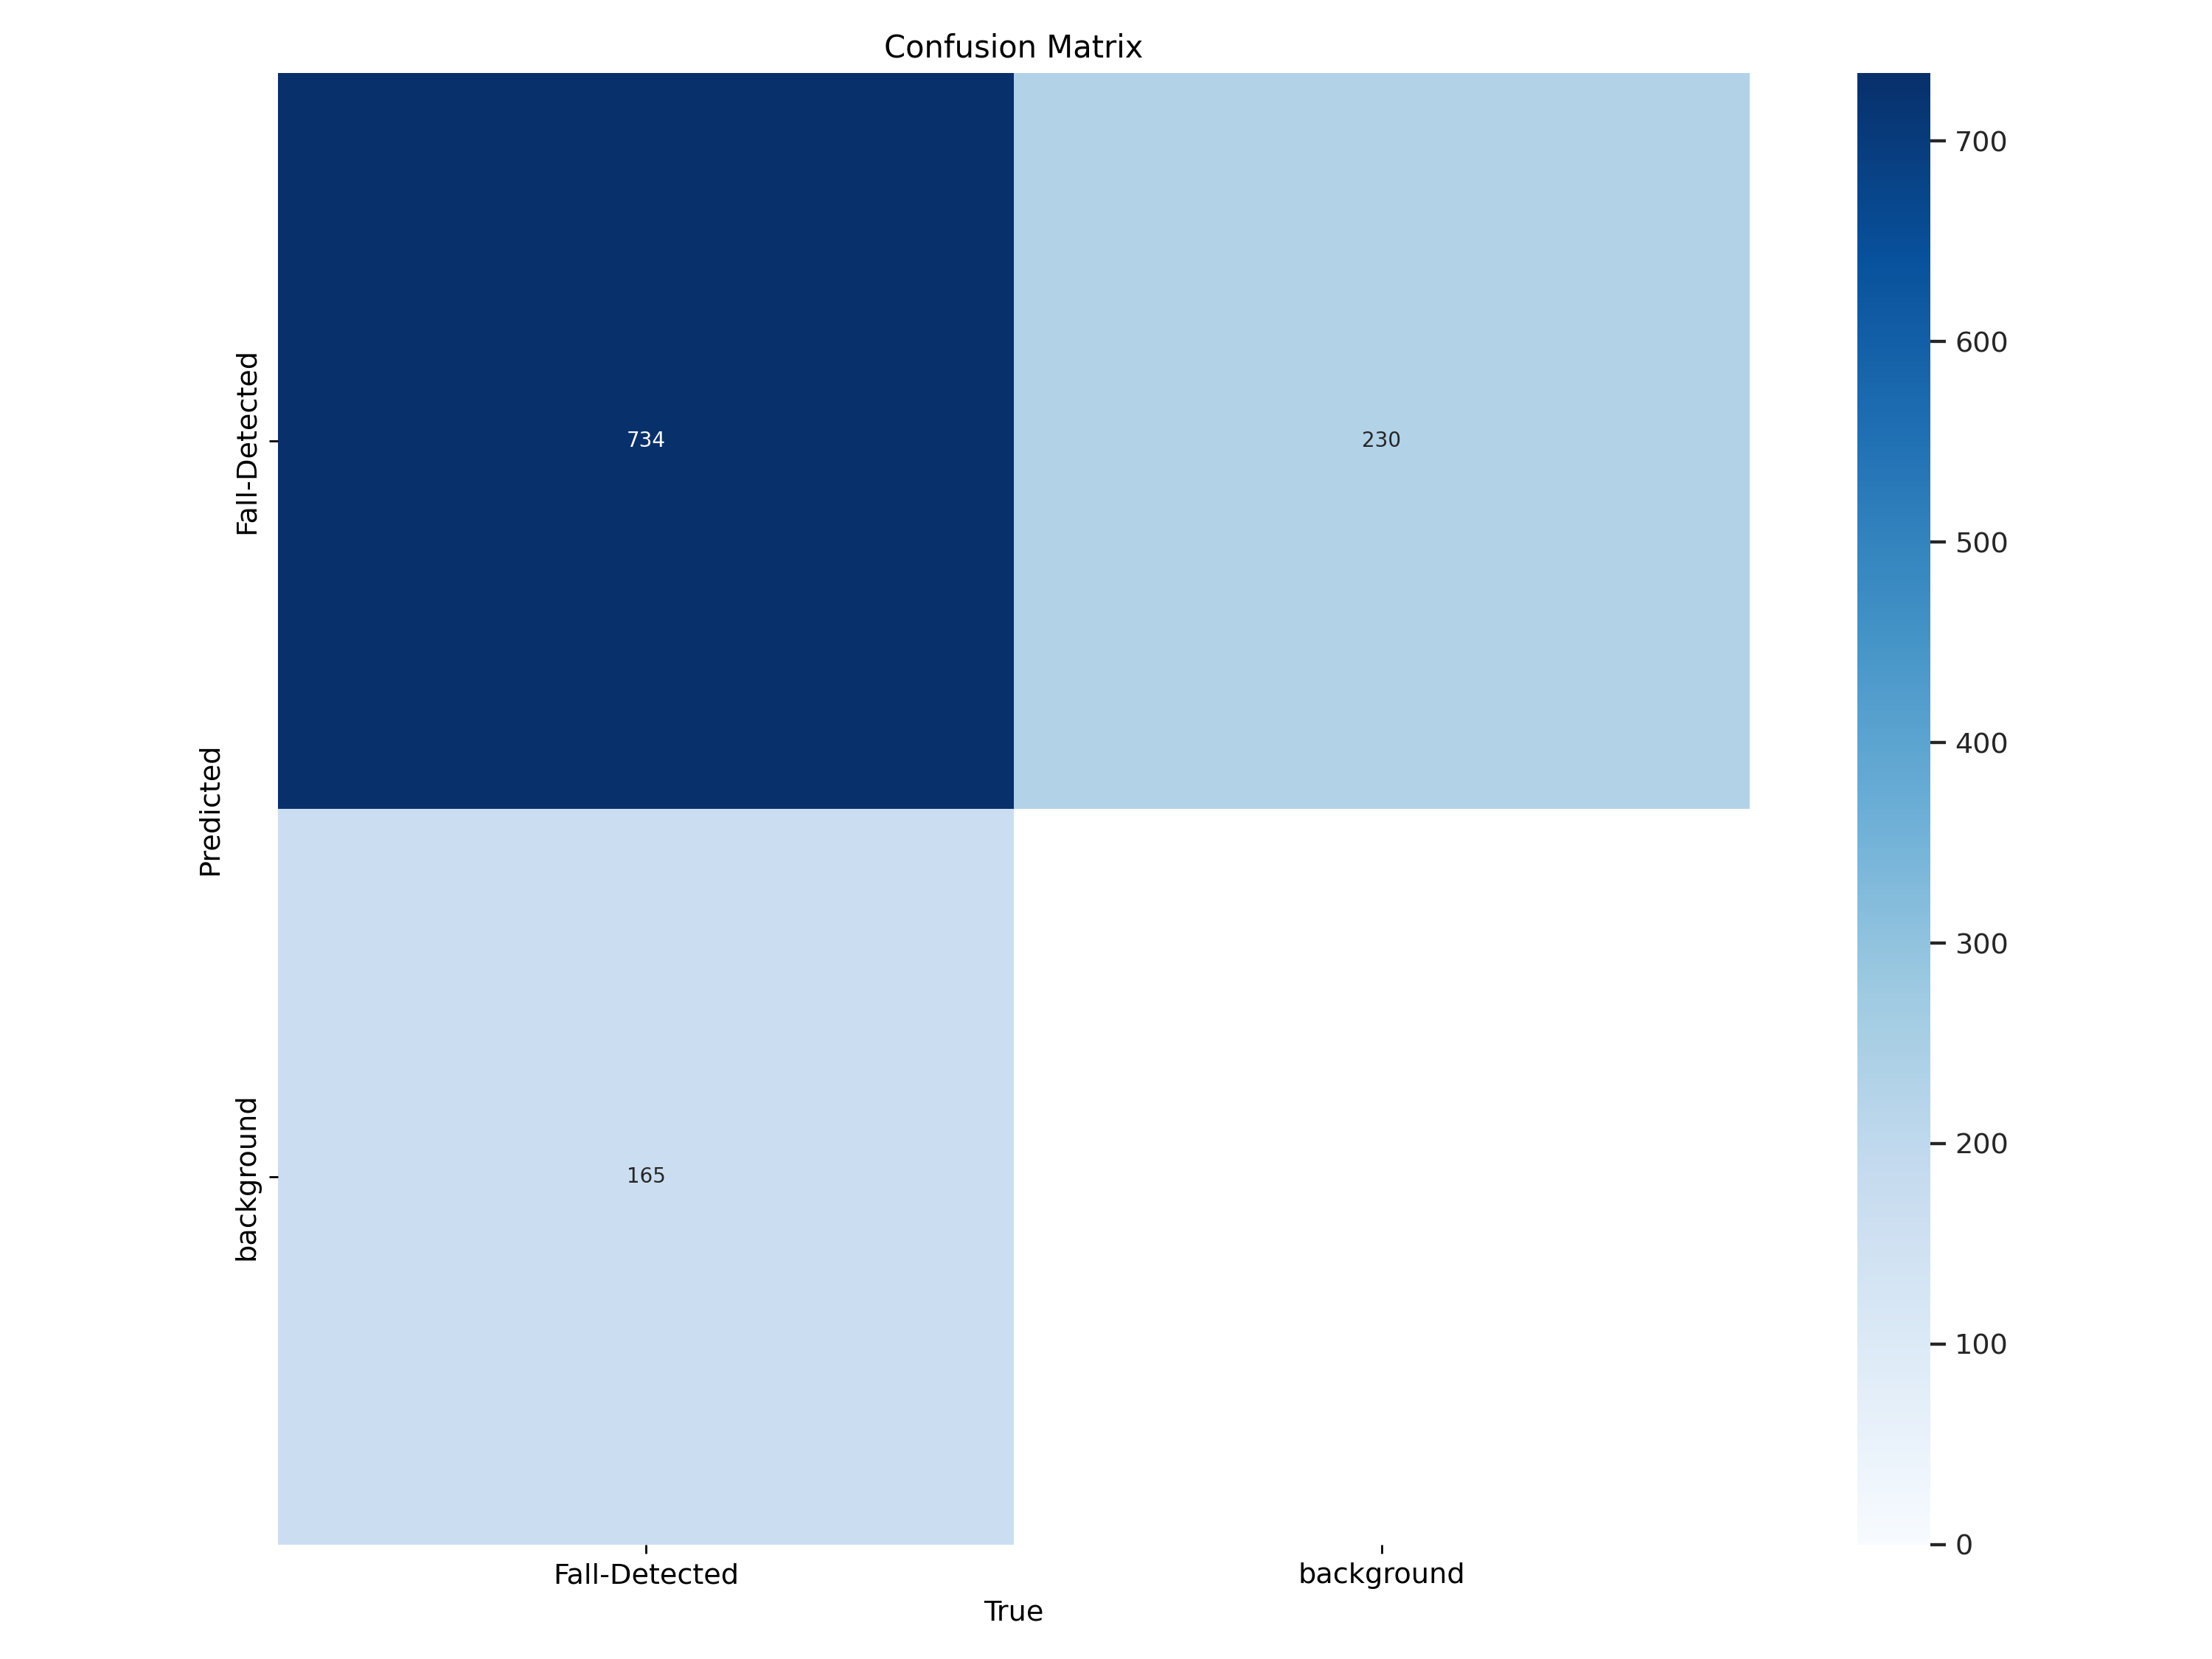

In [ ]:
from IPython.display import Image
Image(filename='/content/runs/detect/train3/confusion_matrix.png')

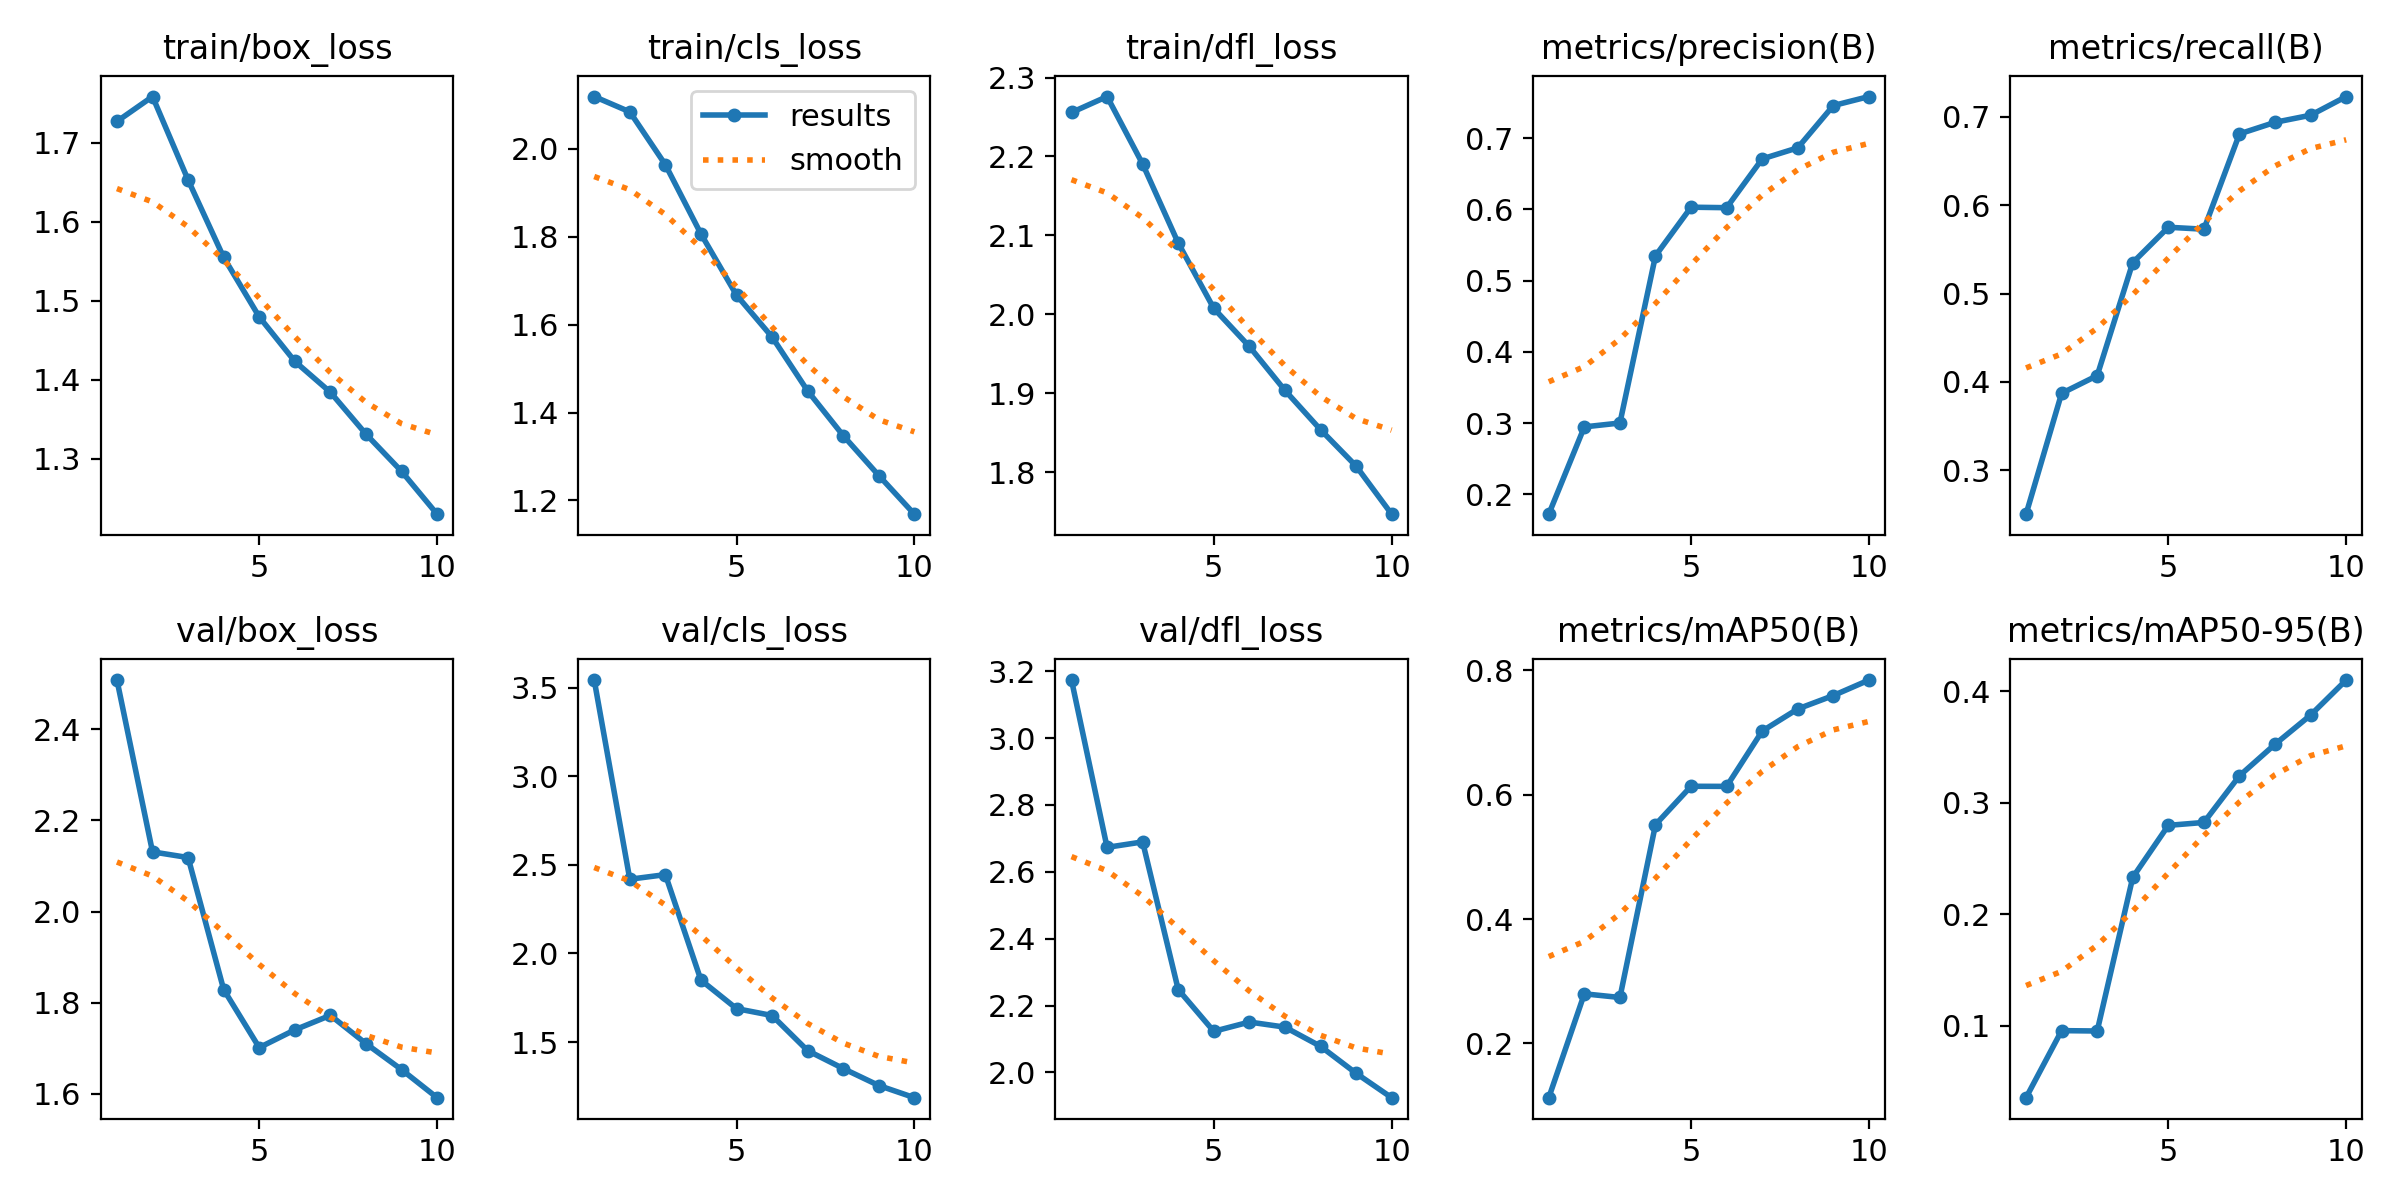

In [ ]:
Image(filename='/content/runs/detect/train3/results.png')


In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train3/weights/best.pt data={dataset.location}/data.yaml

WARNING ⚠️ 'source' argument is missing. Using default 'source=/usr/local/lib/python3.10/dist-packages/ultralytics/assets'.
Ultralytics YOLOv8.2.70 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

image 1/2 /usr/local/lib/python3.10/dist-packages/ultralytics/assets/bus.jpg: 640x480 (no detections), 111.5ms
image 2/2 /usr/local/lib/python3.10/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 Fall-Detecteds, 80.0ms
Speed: 2.9ms preprocess, 95.7ms inference, 292.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train3/weights/best.pt conf=0.5 source={dataset.location}/test/images/

Ultralytics YOLOv8.2.70 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

image 1/450 /content/Fall-Detection-4/test/images/people-1021-_jpg.rf.f614158e545e853dd32da630b11d0c0e.jpg: 640x640 (no detections), 37.1ms
image 2/450 /content/Fall-Detection-4/test/images/people-1022-_jpg.rf.5728f16ac2a94330d2e3d3c0e8b786d8.jpg: 640x640 1 Fall-Detected, 37.3ms
image 3/450 /content/Fall-Detection-4/test/images/people-1034-_jpg.rf.f10308af2ae6dbdffedfe7cdb64a4039.jpg: 640x640 1 Fall-Detected, 37.1ms
image 4/450 /content/Fall-Detection-4/test/images/people-1035-_jpg.rf.a68dbc901e1ffcbd5d0971ee7912f282.jpg: 640x640 (no detections), 37.1ms
image 5/450 /content/Fall-Detection-4/test/images/people-1040-_jpg.rf.59b798fbc620a0d46f83783bcb64723d.jpg: 640x640 (no detections), 37.1ms
image 6/450 /content/Fall-Detection-4/test/images/people-1061-_jpg.rf.61a11a3281f12d2937cc71a2790f41a6.jpg: 640x640 1 Fall-Detect

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/runs/detect/predict2/*.jpg')[:3]:
  display(Image(filename=image_path, width=600))
  print("\n")